### Загрузка датасета COCO и кода COCO API
Необходимо раскомментировать код ниже. В нём происходит скачивание и распаковка датасета COCO.
Кроме того, здесь клонируется репозиторий с кодом COCO API (код для работы с данными из COCO)

Запускать лучше всего в Google Cloab или на другой Linux-машине

In [1]:
!mkdir -p data

!cd data && wget http://images.cocodataset.org/zips/train2017.zip
!cd data && wget http://images.cocodataset.org/zips/val2017.zip
!cd data && wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip

!cd data && unzip -q train2017.zip
!cd data && unzip -q val2017.zip
!cd data && unzip -q annotations_trainval2017.zip

!cd data && git clone https://github.com/cocodataset/cocoapi
!cd data/cocoapi/PythonAPI && make

--2026-01-27 11:30:06--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.115.41, 3.5.25.117, 54.231.236.105, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.115.41|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘train2017.zip’

train2017.zip       100%[===================>]  18.01G  58.0MB/s    in 5m 31s  

2026-01-27 11:35:37 (55.7 MB/s) - ‘train2017.zip’ saved [19336861798/19336861798]

--2026-01-27 11:35:37--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.116.193, 52.217.197.129, 52.217.194.129, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.116.193|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>

### Импорт необходимых библиотек

In [2]:
import os
import skimage.io as io
import numpy as np

### Импорт TensorFlow

In [3]:
import tensorflow as tf
#tf.enable_eager_execution()
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


In [4]:
import tensorflow as tf
import gc

#очистка сессии Keras
tf.keras.backend.clear_session()
gc.collect()

#закрыть все фигуры matplotlib
import matplotlib.pyplot as plt
plt.close('all')

print("Память очищена")

Память очищена


### Импорт библиотеки COCO API
Там содержатся различные функции для чтения и обработки датасета COCO

In [5]:
COCO_ROOT = './data/'
import sys
sys.path.insert(0, os.path.join(COCO_ROOT, 'cocoapi/PythonAPI'))
from pycocotools.coco import COCO

### Наш класс Dataset
Этот класс конструирует экземпляры `tf.data.Dataset` и является универсальным для сегментации (подходит для использования с различными датасетами)

Однако, это абстрактный класс, в котром не реализован метод чтения датасета с диска, так как этот метод может отличаться для разных датасетов

In [6]:
class Dataset():

    def crop_images(self, img, inp_size, random_crop=False):
        shape = tf.shape(img)
        pad = (
            [0, tf.maximum(inp_size - shape[0], 0)],
            [0, tf.maximum(inp_size - shape[1], 0)],
            [0, 0],
        )
        img = tf.pad(img, pad)

        if random_crop:
            shape = tf.shape(img)
            ho = tf.random.uniform([], maxval=shape[0]-inp_size+1, dtype=tf.int32)
            wo = tf.random.uniform([], maxval=shape[1]-inp_size+1, dtype=tf.int32)
            img = img[ho:ho+inp_size, wo:wo+inp_size, :]
        else: # central crop
            shape = tf.shape(img)
            ho = (shape[0] - inp_size) // 2
            wo = (shape[1] - inp_size) // 2
            img = img[ho:ho+inp_size, wo:wo+inp_size, :]

        return img

    def train_dataset(self, batch_size, epochs, inp_size):

        def item_to_images(item):
            random_crop = True
            img_combined = tf.py_function(self.read_images, [item], tf.uint8)
            img_combined = self.crop_images(img_combined, inp_size, random_crop)

            img = tf.cast(img_combined[...,:3], tf.float32) / np.float32(255.)
            mask_class = tf.cast(img_combined[...,3:4], tf.float32)
            return img, mask_class

        dataset = tf.data.Dataset.from_tensor_slices(self.img_list)
        dataset = dataset.shuffle(buffer_size=len(self.img_list))
        dataset = dataset.map(item_to_images, num_parallel_calls=tf.data.AUTOTUNE)  # Параллельный map
        dataset = dataset.cache()  # Кэшируем после map (ускоряет при повторных эпохах)
        dataset = dataset.repeat(epochs)
        dataset = dataset.batch(batch_size, drop_remainder=True)
        dataset = dataset.prefetch(tf.data.AUTOTUNE)


        return dataset

    def val_dataset(self, batch_size, inp_size):

        def item_to_images(item):
            random_crop = False
            img_combined = tf.py_function(self.read_images, [item], tf.uint8)
            img_combined = self.crop_images(img_combined, inp_size, random_crop)

            img = tf.cast(img_combined[...,:3], tf.float32) / np.float32(255.)
            mask_class = tf.cast(img_combined[...,3:4], tf.float32)
            return img, mask_class

        dataset = tf.data.Dataset.from_tensor_slices(self.img_list)
        dataset = dataset.map(item_to_images, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.cache()
        dataset = dataset.batch(batch_size, drop_remainder=True)
        dataset = dataset.prefetch(tf.data.AUTOTUNE)

        return dataset

### Наш класс COCO_Dataset
Класс, наследованный от нашего класса `Dataset`, в котром реализован метод `read_images`, специфичный для датасета COCO

In [7]:
class COCO_Dataset(Dataset):

    def __init__(self, sublist):
        ann_file_fpath = os.path.join(COCO_ROOT, 'annotations', 'instances_'+sublist+'2017.json')
        self.coco = COCO(ann_file_fpath)
        self.cat_ids = self.coco.getCatIds(catNms=['person'])
        self.img_list = self.coco.getImgIds(catIds=self.cat_ids)

    def read_images(self, img_id):
        img_id = int(img_id.numpy())
        img_data = self.coco.loadImgs(img_id)[0]
        img_fname = '/'.join(img_data['coco_url'].split('/')[-2:])

        img = io.imread(os.path.join(COCO_ROOT, img_fname))
        if len(img.shape) == 2:
            img = np.tile(img[..., None], (1, 1, 3))

        ann_ids = self.coco.getAnnIds(imgIds=img_data['id'], catIds=self.cat_ids, iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)
        mask_class = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        for i in range(len(anns)):
            mask_class += self.coco.annToMask(anns[i])
        mask_class = (mask_class > 0).astype(np.uint8)

        img_combined = np.concatenate([img, mask_class[..., None]], axis=2)

        return img_combined

### Создание обучающего и вализационного датасета
Сначала создаются два экземпляра класса `COCO_Dataset`, в конструкторе которого указывается тип датасета (указание для COCO - откуда какие читать изображения)

Далее вызываются функции `train_dataset` и `val_dataset` которые создают экземпляры `tf.data.Dataset` (в первом и втором случае логика и пайплайн данных в этих датасетов отличаются)

In [1]:
#из-за ограничения ресурсов оперативной памяти Гугл Колаб, берем параметры: batch_size=16, inp_size=128
COCO_dataset_train = COCO_Dataset('train')
COCO_dataset_val = COCO_Dataset('val')

#train_ds = COCO_dataset_train.train_dataset(...)
#val_ds = COCO_dataset_val.val_dataset(...)
train_ds = COCO_dataset_train.train_dataset(batch_size=16, epochs=10, inp_size=128)
val_ds = COCO_dataset_val.val_dataset(batch_size=16, inp_size=128)

NameError: name 'COCO_Dataset' is not defined

In [9]:
class ASPPBlock(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.conv1 = tf.keras.layers.Conv2D(256, (1, 1), padding='same', activation='relu')
        self.conv2 = tf.keras.layers.Conv2D(256, (3, 3), dilation_rate=6, padding='same', activation='relu')
        self.conv3 = tf.keras.layers.Conv2D(256, (3, 3), dilation_rate=12, padding='same', activation='relu')
        self.conv4 = tf.keras.layers.Conv2D(256, (3, 3), dilation_rate=18, padding='same', activation='relu')
        self.conv5 = tf.keras.layers.Conv2D(256, (1, 1), padding='same', activation='relu')

        self.concat = tf.keras.layers.Concatenate(axis=3)

    def call(self, inp, is_training=False):
        out1 = self.conv1(inp)
        out2 = self.conv2(inp)
        out3 = self.conv3(inp)
        out4 = self.conv4(inp)
        out = self.concat([out1, out2, out3, out4])
        out = self.conv5(out)
        return out

class ASPPNet(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.conv1 = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')
        self.conv2 = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')
        self.conv3 = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')
        self.conv4 = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')
        self.conv5 = tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu')
        self.conv6 = tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu')
        self.conv7 = tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu')
        self.conv8 = tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu')
        self.conv9 = tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu')
        self.conv10 = tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu')

        self.conv11 = tf.keras.layers.Conv2D(48, (1, 1), padding='same', activation='relu')
        self.conv12 = tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu')
        self.conv13 = tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu')
        self.conv14 = tf.keras.layers.Conv2D(1, (1, 1), padding='same', activation=None)

        self.maxpool = tf.keras.layers.MaxPooling2D((2, 2), (2, 2), padding='same')
        self.concat_layer = tf.keras.layers.Concatenate(axis=3)

        self.aspp = ASPPBlock()

    def call(self, x):

        out = self.conv1(x)
        out = self.conv2(out)
        out = self.maxpool(out)
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.maxpool(out)
        out = self.conv5(out)
        out = self.conv6(out)
        out_enc_mid = out
        out = self.maxpool(out)
        out = self.conv7(out)
        out = self.conv8(out)
        out = self.maxpool(out)
        out = self.conv9(out)
        out = self.conv10(out)

        out = self.aspp(out)

        out = tf.image.resize(out, tf.shape(out_enc_mid)[1:3], tf.image.ResizeMethod.BILINEAR)

        out_enc_mid = self.conv11(out_enc_mid)

        out = self.concat_layer([out, out_enc_mid])

        out = self.conv12(out)
        out = self.conv13(out)
        out = self.conv14(out)

        out = tf.image.resize(out, tf.shape(x)[1:3], tf.image.ResizeMethod.BILINEAR)
        out = tf.nn.sigmoid(out)
        return out

model = ASPPNet()

In [10]:
#строим модель передав тестовый тензор

test_input = tf.random.normal([1, 128, 128, 3])
_ = model(test_input)

In [11]:
#компилируем модель
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
import os
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

#создаём папку для сохранения весов
checkpoint_dir = r'C:\Users\user0907\dowloadPython_clean\checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Папка для чекпоинтов: {checkpoint_dir}")


#настраиваем колбеки
checkpoint_full = ModelCheckpoint(
    os.path.join(checkpoint_dir, 'full_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    save_weights_only=False,  #сохраняем всю модель
    verbose=1
)

#чекпоинт для всей модели

checkpoint = ModelCheckpoint(
    os.path.join(checkpoint_dir, 'epoch_{epoch:02d}_weights.weights.h5'),
    monitor='val_loss',
    save_best_only=False,#сохранять каждую эпоху
    save_weights_only=True,
    verbose=1
)


early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-8,
    verbose=1
)

#колбек для логов
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=os.path.join(checkpoint_dir, 'logs'),
    histogram_freq=1
)

callbacks_list = [checkpoint, checkpoint_full, early_stop, reduce_lr, tensorboard_callback]

Папка для чекпоинтов: C:\Users\user0907\dowloadPython_clean\checkpoints


In [13]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_before_after(images, true_masks, model=None, model_name="Untrained"):
    num_samples = min(3, len(images))

    if model:
        predictions = model.predict(images[:num_samples])
    else:
        predictions = np.zeros_like(true_masks[:num_samples])

    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))

    for i in range(num_samples):
        #исходное изображение
        axes[i, 0].imshow(images[i])
        axes[i, 0].set_title(f'Input {i+1}')
        axes[i, 0].axis('off')

        #истинная маска
        axes[i, 1].imshow(true_masks[i, ..., 0], cmap='gray')
        axes[i, 1].set_title('True Mask')
        axes[i, 1].axis('off')

        #предсказание или пусто
        axes[i, 2].imshow(predictions[i, ..., 0] > 0.5, cmap='gray')
        axes[i, 2].set_title(f'Prediction ({model_name})')
        axes[i, 2].axis('off')

        #ошибка предсказания
        if model:
            error = np.abs(true_masks[i, ..., 0] - (predictions[i, ..., 0] > 0.5))
            axes[i, 3].imshow(error, cmap='Reds')
            axes[i, 3].set_title('Error (Red=wrong)')
        else:
            axes[i, 3].imshow(np.zeros_like(true_masks[i, ..., 0]), cmap='gray')
            axes[i, 3].set_title('No model yet')
        axes[i, 3].axis('off')

    plt.suptitle(f'Model: {model_name}', fontsize=16)
    plt.tight_layout()
    plt.show()

In [14]:
import numpy as np

#сохраняем рандомный батч до обучения
for test_images, test_masks in val_ds.take(1):
    test_images_before = test_images.numpy()
    test_masks_before = test_masks.numpy()
    break

print(f"Сохранено {len(test_images_before)} изображений для сравнения")

Сохранено 16 изображений для сравнения


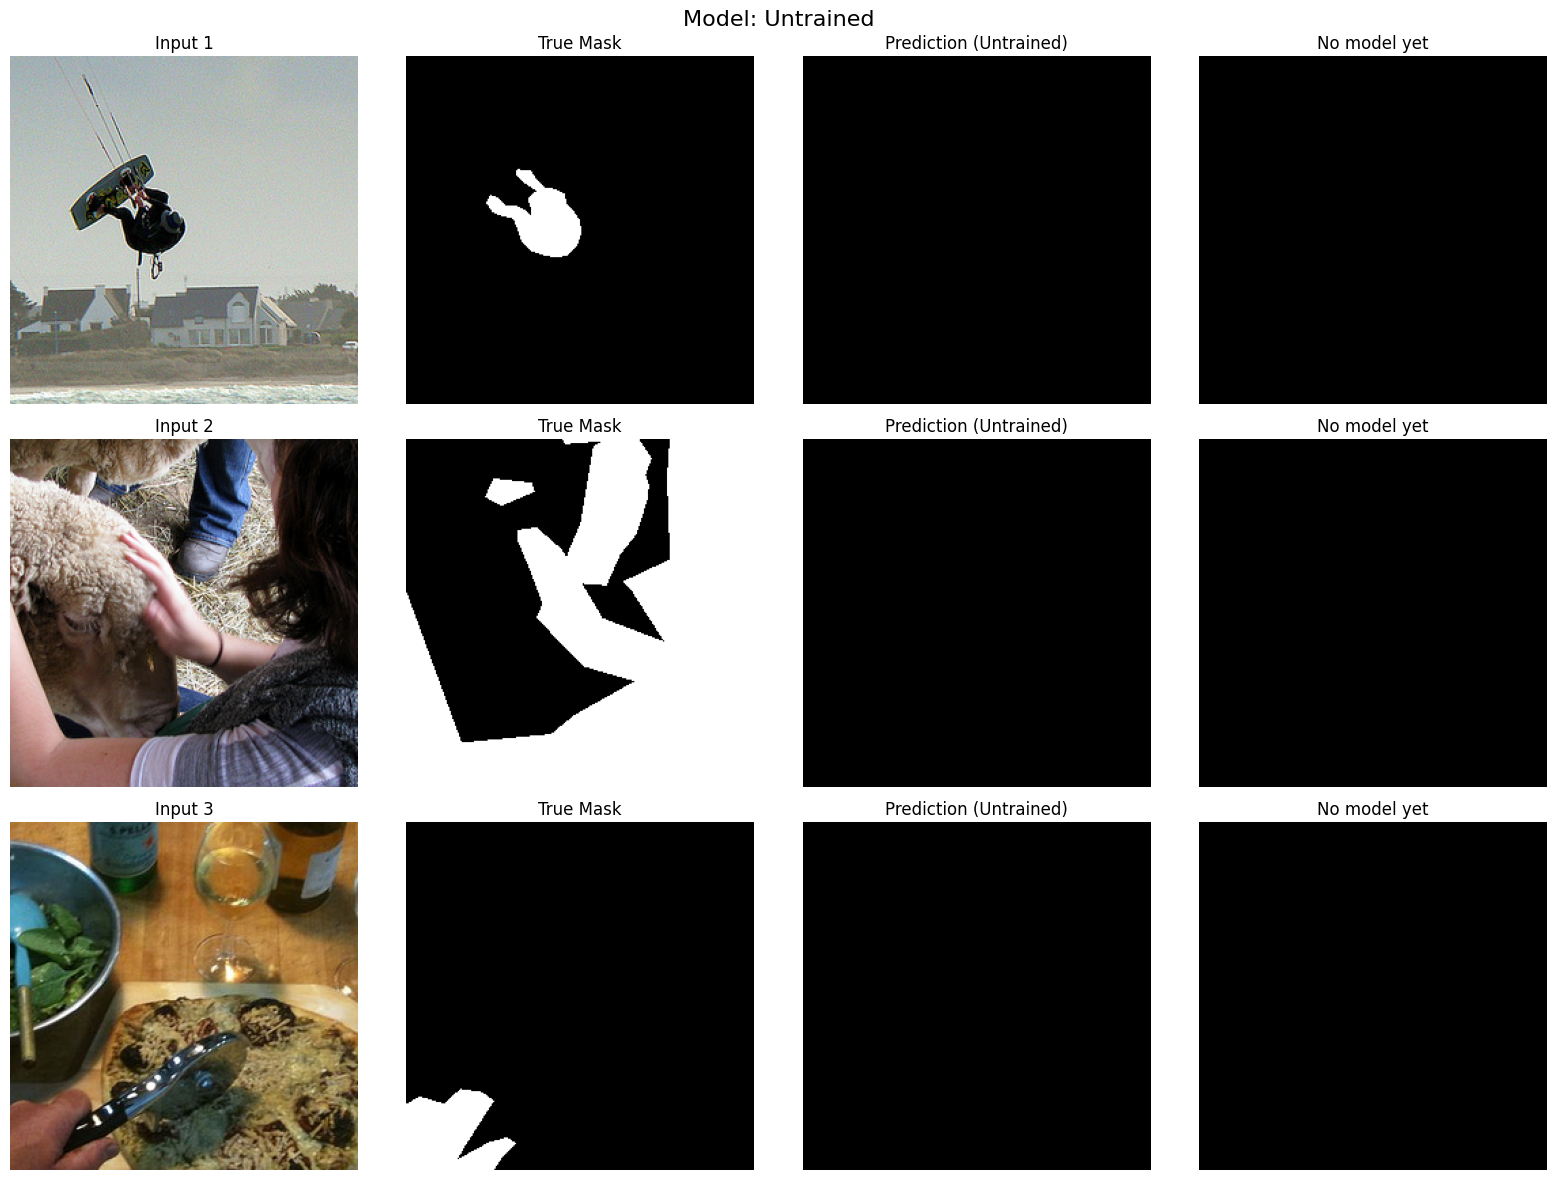

In [17]:
#визуализируем до обучения
visualize_before_after(test_images_before, test_masks_before, model=None)

In [ ]:
#ресурсы Гугл Колаб позволяют взять только 1000 батчей вместо 20035
train_ds_small = train_ds.take(1000)
val_ds_small = val_ds.take(200)

#обучаем модель
history = model.fit(
    train_ds_small,
    validation_data=val_ds_small,
    epochs=2,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/2
 415/1000 ━━━━━━━━━━━━━━━━━━━━ 6:56 712ms/step - accuracy: 0.7725 - loss: 0.5354

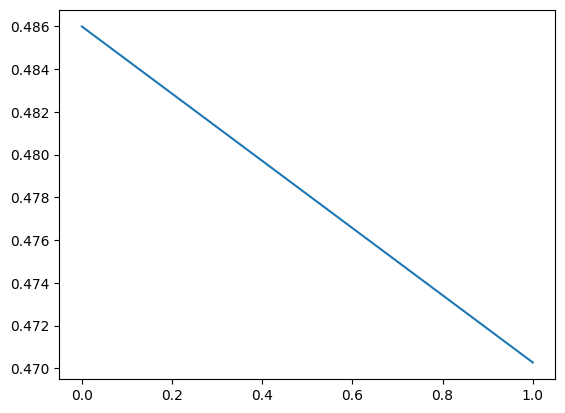

In [ ]:
#проверяем историю обучения
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

#график точности
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Точность (Accuracy)')
axes[0].set_xlabel('Эпоха')
axes[0].legend()

#график потерь
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Потери (Loss)')
axes[1].set_xlabel('Эпоха')
axes[1].legend()
#понижение рейта обучения
if 'learning_rate' in history.history:
    axes[2].plot(history.history['learning_rate'], marker='o')
    axes[2].set_title('Learning Rate Schedule')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('LR')


plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


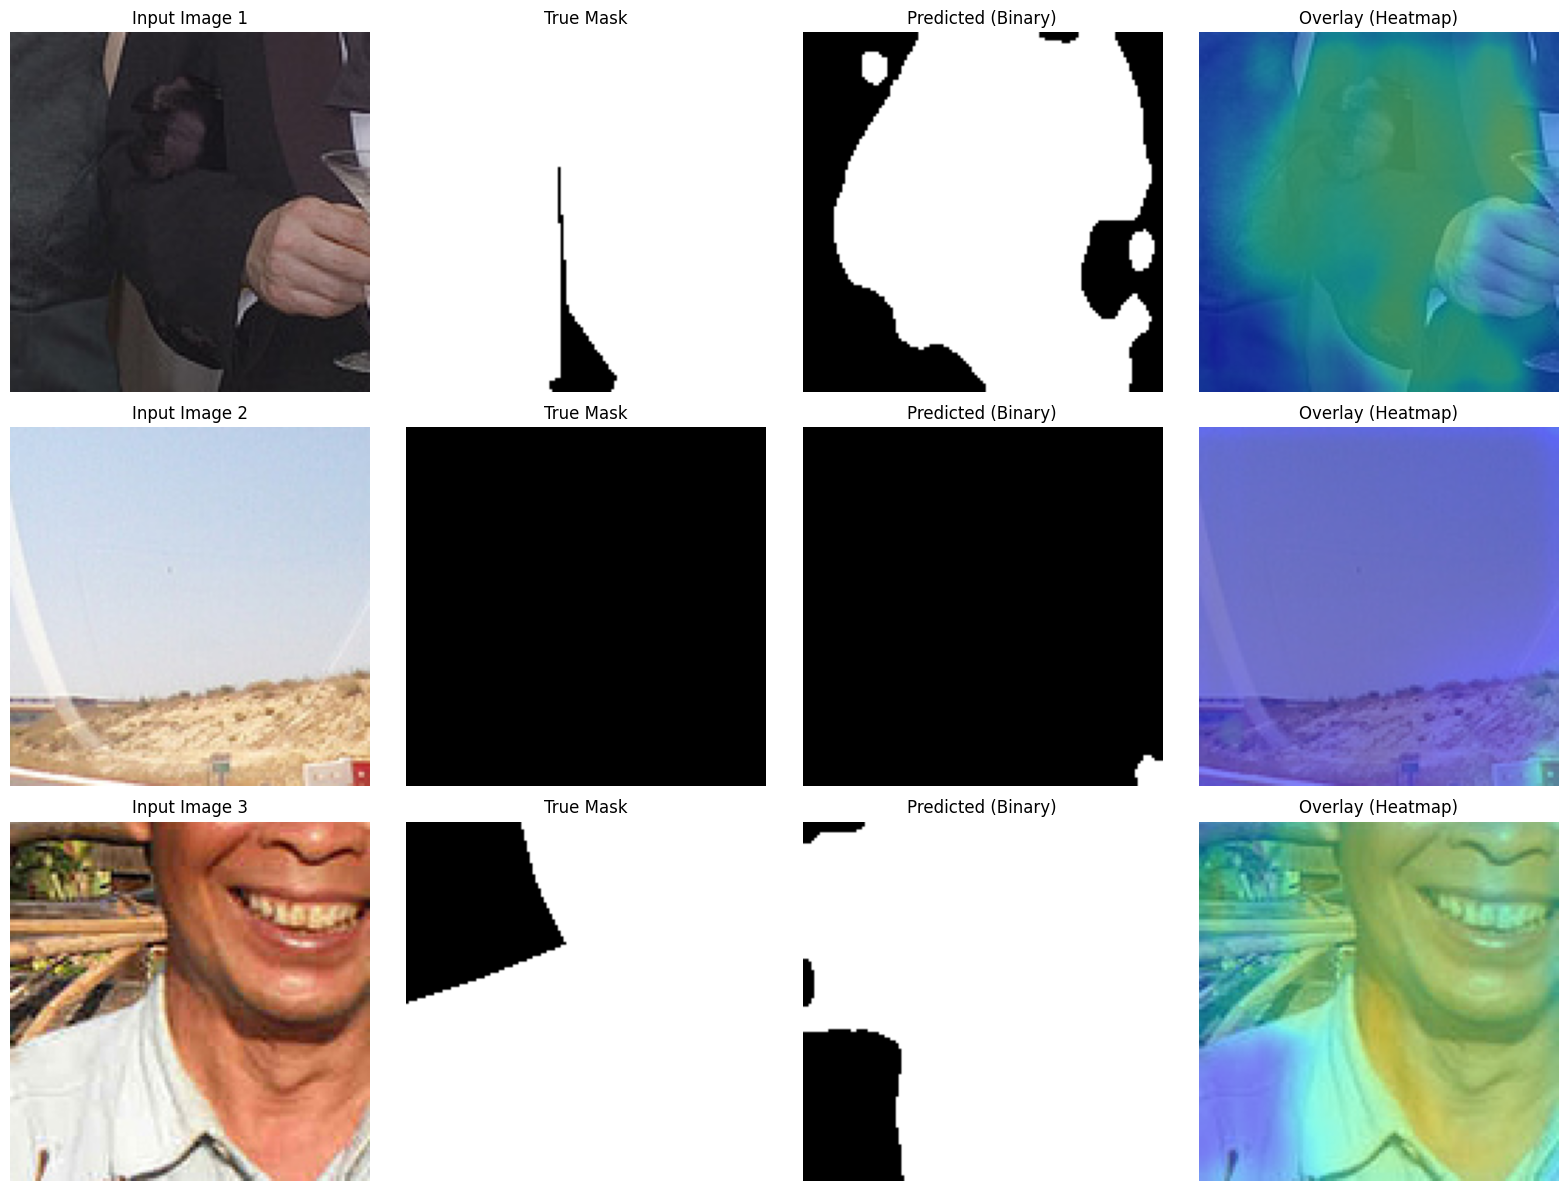

In [ ]:
#визуализируем после обучения на тех же изображениях
visualize_predictions_before_after(
    test_images_before,
    test_masks_before,
    model=model,
    title="после обучения"
)